In [47]:
from sklearn.preprocessing import normalize
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dense, Dropout ,GRU
from tensorflow import keras
from keras.callbacks import History, ReduceLROnPlateau
from tensorflow.keras.optimizers import SGD, Adam, RMSprop
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import Sequential
from keras.activations import *

In [39]:
from google.colab import files
uploaded = files.upload()

Saving telescope_data.csv to telescope_data (1).csv


In [52]:
import pandas as pd
df = pd.read_csv('telescope_data.csv')

df.head()

,Unnamed: 0,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [53]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [54]:
df.drop("Unnamed: 0",axis=1,inplace=True)

In [55]:
X = df.drop("class",axis=1)
y= df["class"]

In [67]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])


print(df['class'].unique())

[0 1]


<Axes: xlabel='fLength', ylabel='fWidth'>

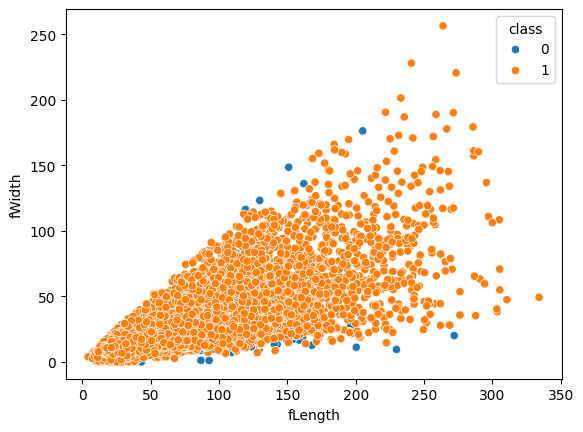

In [57]:
sns.scatterplot(x="fLength",y="fWidth",data = df , hue="class")

In [70]:
X = df.drop("class", axis=1).values.astype('float32') # her seyi floataa cevridim
y = df["class"].values.astype('float32')

In [81]:
df.dtypes

,0
fLength,float64
fWidth,float64
fSize,float64
fConc,float64
fConc1,float64
fAsym,float64
fM3Long,float64
fM3Trans,float64
fAlpha,float64
fDist,float64


In [71]:
x_train,x_test,y_train,y_test= train_test_split(X,y,test_size=0.2)

In [72]:
len(x_train)

15216

In [73]:
df["class"].nunique() ##iki sinif var

2

In [74]:
model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(X.shape[1],))) ##ilk hidden layer 32 neyron x sutun sayi qeder
model.add(Dropout(0.2)) ##overfittingin qarsisini lamaq ucun neyronlarin 20 fazini oldurur random olaraq
model.add(Dense(16, activation='relu')) # ikinci hidden layer 16 neyron
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid')) ##clas ikidir deye sigmoid verdim cox olsa softmax olaacqdi


In [75]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897 (3.50 KB)

 Trainable params: 897 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

In [76]:
adam = Adam(learning_rate= 0.01) ##  adam ist elemisem optimallasdimaq ucun #learning_rate= 0.01 azaldiqca yavas oyrenir

In [83]:
history = History()
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [84]:
model.fit(x_train,y_train, epochs=25, callbacks=[history],batch_size=32,validation_data=(x_test,y_test))

Epoch 1/25
476/476 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8147 - loss: 0.4165 - val_accuracy: 0.8325 - val_loss: 0.3968
Epoch 2/25
476/476 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8145 - loss: 0.4143 - val_accuracy: 0.8247 - val_loss: 0.4051
Epoch 3/25
476/476 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8122 - loss: 0.4150 - val_accuracy: 0.8304 - val_loss: 0.3940
Epoch 4/25
476/476 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8140 - loss: 0.4147 - val_accuracy: 0.8273 - val_loss: 0.3955
Epoch 5/25
476/476 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8165 - loss: 0.4094 - val_accuracy: 0.8286 - val_loss: 0.3952
Epoch 6/25
476/476 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8163 - loss: 0.4090 - val_accuracy: 0.8268 - val_loss: 0.3956
Epoch 7/25
476/476 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8176 - loss: 0.4072 - val_accuracy: 0.8281 - val_loss: 0.3978
Epoch 8/25
476/476 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8199 - loss: 0.4055 - val_accuracy: 0.

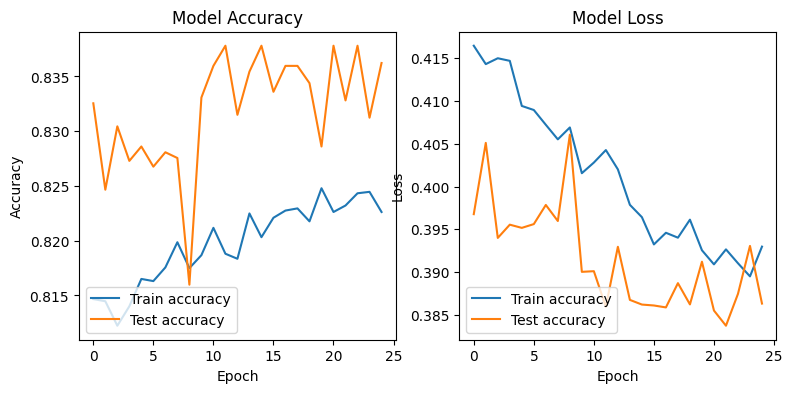

In [97]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train accuracy', 'Test accuracy'], loc='lower left')

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train accuracy', 'Test accuracy'], loc='lower left')
##her iki xett bir brine yaxindir  dmeli overfiting yoxdur accucary 82-82 fazidir
##umumi trend yaxsidir ikside de mavi xeet cox yuxarida narinci cox asagida olsaydi overfiiting olardi

In [88]:
y_pred = model.predict(x_test)

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


In [89]:
y_pred

array([[0.2971829 ],
       [0.04334772],
       [0.3737127 ],
       ...,
       [0.15533306],
       [0.07944375],
       [0.30409926]], dtype=float32)

In [90]:
y_pred = y_pred.argmax(axis=1)

In [91]:
y_pred


array([0, 0, 0, ..., 0, 0, 0])

In [93]:
from sklearn.metrics import classification_report
y_test

array([0., 0., 1., ..., 0., 0., 1.], dtype=float32)

In [94]:
len(y_test)



3804

In [95]:
np.sum(y_pred == y_test.argmax(axis=1))

AxisError: axis 1 is out of bounds for array of dimension 1